Downloading data

In [ ]:
!unzip /content/archive.zip -d /content/raw

Archive:  /content/archive.zip
  inflating: /content/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [ ]:
!pip install xgboost torch scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import seaborn as sns
from xgboost import XGBClassifier
import torch
import random

pd.set_option('display.max_columns', None)

RANDOM_SEED = 52
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)


In [ ]:
PATH =  "/content/raw/"

df = pd.read_csv(PATH + "WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Basic EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
data_columns = df.apply(lambda x: x.nunique())
columns_with_two  = data_columns[data_columns == 2 ].index
columns_with_three  = data_columns[data_columns == 3 ].index
columns_with_four  = data_columns[data_columns == 4 ].index
data_columns

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


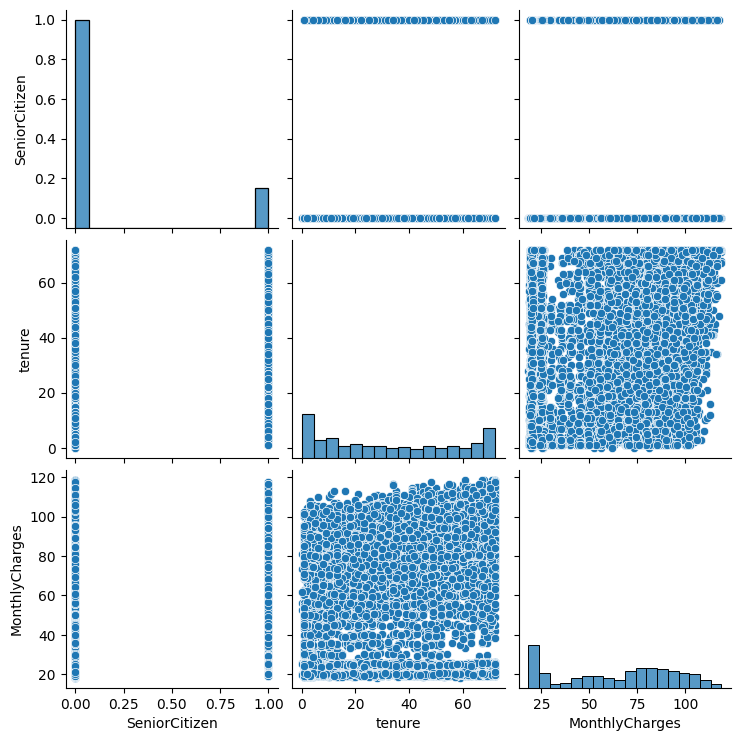

In [ ]:
sns.pairplot(df)

<Axes: >

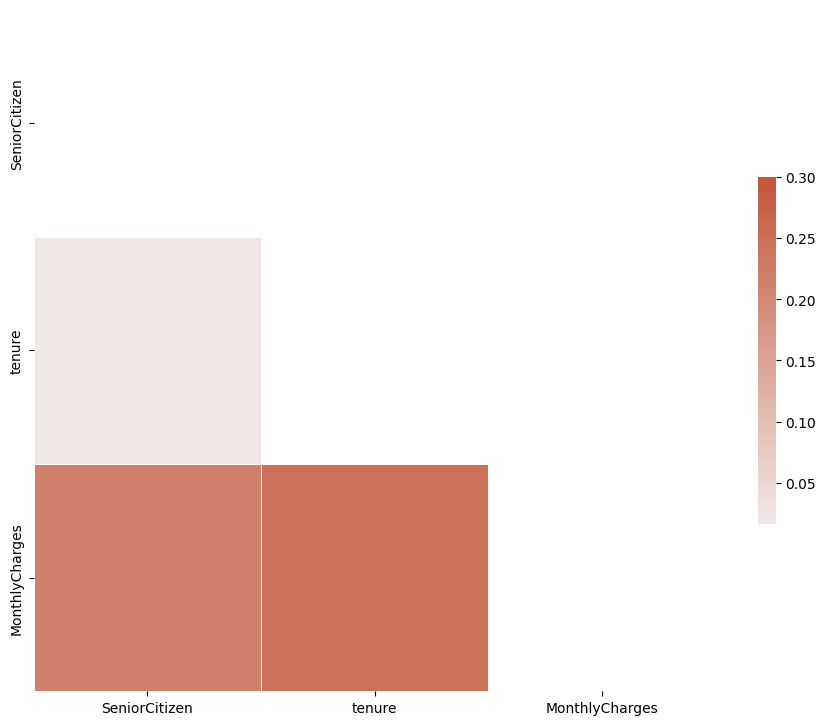

In [ ]:
corr = df.corr(numeric_only= True)

mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

# Data preprocessing

In [ ]:
df = df.drop('customerID',axis = 1)
df = df.drop(df[df.TotalCharges == ' '].index, axis = 0)


In [ ]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = df['TotalCharges'].astype('float64')

In [ ]:
def remove_outliers_iqr(data, columns):
    mask = pd.Series(True, index=data.index)
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask &= data[col].between(lower, upper)
    return data[mask]

df = remove_outliers_iqr(df, ['tenure', 'MonthlyCharges', 'TotalCharges'])

service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumServices'] = (df[service_cols] == 'Yes').sum(axis=1)
df['AvgMonthlyCharge'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

In [ ]:
object_cols = df.select_dtypes(include=['object']).columns
df[object_cols] = df[object_cols].astype('category')

X = df.drop(columns='Churn')
y = df['Churn'].map({"Yes": 1, "No": 0})

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

num = X.select_dtypes(include=['int64', 'float64']).columns.to_list()
cat = X.select_dtypes(include=['category']).columns.to_list()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat)
    ]
)

In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=RANDOM_SEED)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# Preprocessing done: added IQR outlier removal and two engineered features (NumServices, AvgMonthlyCharge) above

# Now training model + logging it

In [ ]:
!pip install wandb


In [ ]:
!wandb login

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: geradototez (geradototez-innopolis-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


For the notebook, `!wandb login` is fine, but the automated pipeline runs inside Docker/Airflow with no terminal to type into. There, swap it for `wandb.login(key=os.environ["WANDB_API_KEY"])` and pass `WANDB_API_KEY` into the container as an env var.

In [23]:
import os
import joblib
import xgboost as xgb
import wandb
from wandb.integration.xgboost import WandbCallback
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

#wandb.login(key=os.environ["WANDB_API_KEY"])

config = {
    "objective": "binary:logistic",
    "eta": 0.1,
    "max_depth": 6,
    "n_estimators": 300,
    "random_state": RANDOM_SEED
}

run = wandb.init(project="pmldl-telco-churn", config=config)

model = xgb.XGBClassifier(
    objective=config["objective"],
    learning_rate=config["eta"],
    max_depth=config["max_depth"],
    n_estimators=config["n_estimators"],
    eval_metric=["logloss", "auc"],
    early_stopping_rounds=20,
    random_state=config["random_state"],
    callbacks=[WandbCallback(log_model=True)]
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

metrics = {
    "roc_auc": roc_auc_score(y_test, y_proba),
    "f1": f1_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "best_iteration": model.best_iteration
}

wandb.log(metrics)
run.finish()

metrics

best_iteration,▁▁
best_score,▁
epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
f1,▁
precision,▁
recall,▁
roc_auc,▁
validation_0-auc,▁▂▂▂▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█████
validation_0-logloss,█▇▆▆▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
validation_1-auc,▁▄▅▆▇▇▇▇█▇▇▇██████▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▆▆▇
+1,...


{'roc_auc': np.float64(0.8582072360758084),
 'f1': 0.571900826446281,
 'precision': 0.7489177489177489,
 'recall': 0.4625668449197861,
 'best_iteration': 16}

In [24]:
thresholds = np.linspace(0.1, 0.9, 33)
f1_by_threshold = [f1_score(y_test, (y_proba >= t).astype(int)) for t in thresholds]
best_threshold = float(thresholds[int(np.argmax(f1_by_threshold))])
best_f1 = max(f1_by_threshold)

best_threshold, best_f1

(0.375, 0.6508728179551122)

In [25]:
os.makedirs("models", exist_ok=True)
joblib.dump({"preprocessor": preprocessor, "model": model}, "models/churn_model.pkl")

['models/churn_model.pkl']